In [2]:
import pandas as pd
df = pd.read_csv(r"C:\Users\chaym\Downloads\supermarket_sales.csv")
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [3]:
df.shape

(1000, 17)

In [4]:
# Explorer les données
print(df.info())
print(df.describe())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [5]:
# Supprimer les doublons
df.drop_duplicates(inplace=True)

In [6]:
#: Convertir la colonne Date en datetime
df['Date'] = pd.to_datetime(df['Date'])

In [7]:

# Créer des nouvelles colonnes
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.day_name()

In [8]:
#  Vérifier à nouveau
print(df.head())

    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   

             Product line  Unit price  Quantity   Tax 5%     Total       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715 2019-01-05   
1  Electronic accessories       15.28         5   3.8200   80.2200 2019-03-08   
2      Home and lifestyle       46.33         7  16.2155  340.5255 2019-03-03   
3       Health and beauty       58.22         8  23.2880  489.0480 2019-01-27   
4       Sports and travel       86.31         7  30.2085  634.3785 2019-02-08   

    Time      Payment    cogs  gross margin percentage  gross income  Rating  \
0  13:08      Ewallet  522.83                 4.761905       26.1415     9.1   
1  1

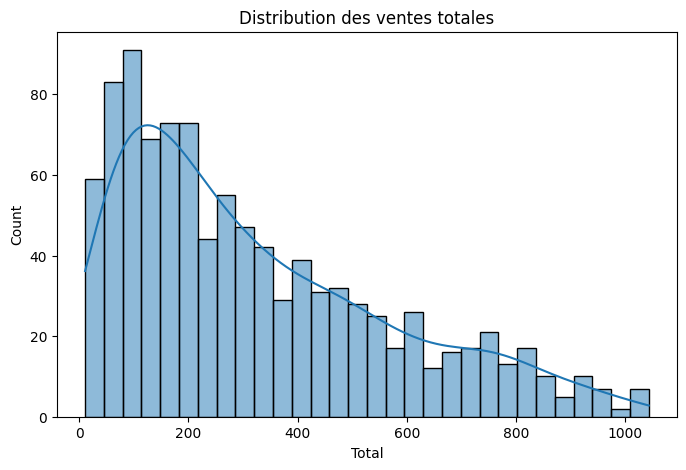

In [9]:
# Visualisations statiques (Matplotlib & Seaborn)
import matplotlib.pyplot as plt
import seaborn as sns

# Histogramme du Total des ventes
plt.figure(figsize=(8,5))
sns.histplot(df['Total'], bins=30, kde=True)
plt.title("Distribution des ventes totales")
plt.show()


C:\Users\chaym\AppData\Local\Temp\ipykernel_29072\1411970044.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='City', y='Total', data=df, ci=None)


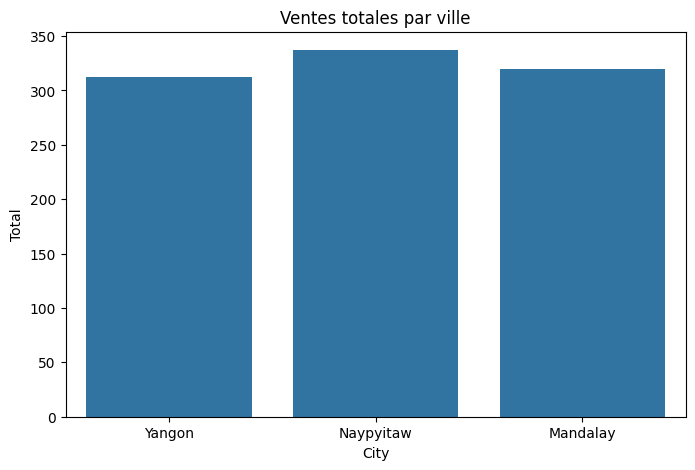

In [10]:
# Ventes par ville (bar plot)
plt.figure(figsize=(8,5))
sns.barplot(x='City', y='Total', data=df, ci=None)
plt.title("Ventes totales par ville")
plt.show()

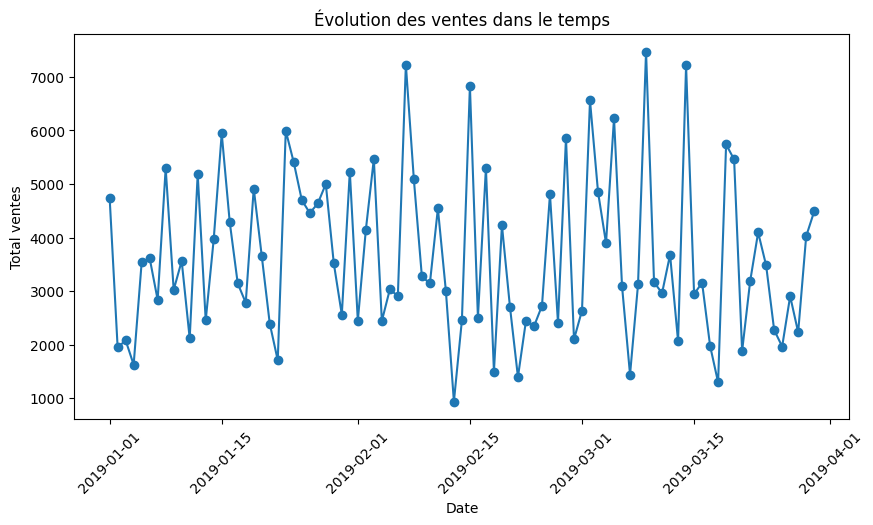

In [11]:
# Évolution des ventes dans le temps (line plot)
df_time = df.groupby('Date')['Total'].sum().reset_index()
plt.figure(figsize=(10,5))
plt.plot(df_time['Date'], df_time['Total'], marker='o')
plt.title("Évolution des ventes dans le temps")
plt.xlabel("Date")
plt.ylabel("Total ventes")
plt.xticks(rotation=45)
plt.show()

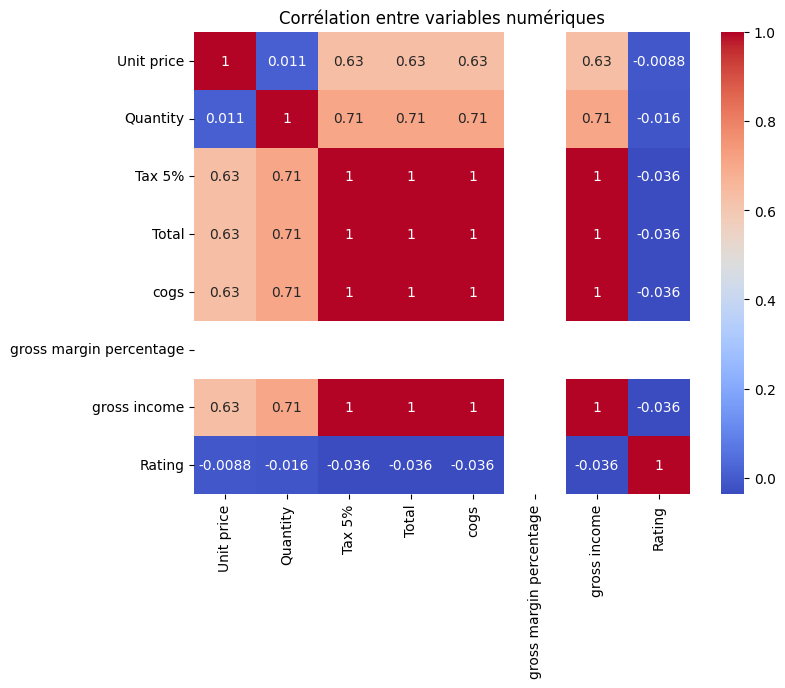

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sélection des colonnes numériques
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Heatmap de corrélation
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Corrélation entre variables numériques")
plt.show()

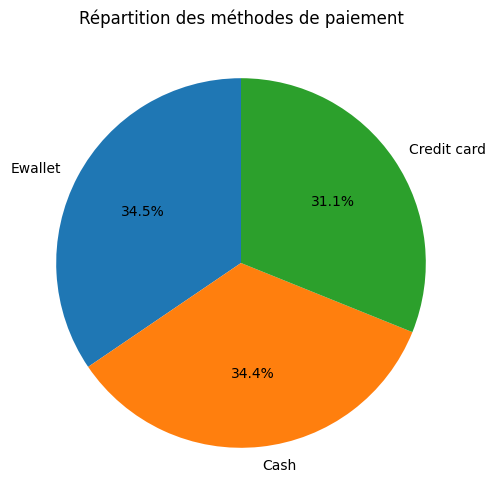

In [13]:
# Camembert des méthodes de paiement
payment_counts = df['Payment'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Répartition des méthodes de paiement")
plt.show()